# 03 — Prompt-length sweep (Qwen stream)

Target: `single_model_llm_serving` `:8000` — `POST /generate_stream`.

Fix concurrency at **1** (isolate prefill → TTFT; no queue from oversubscribe).
Decode length stays ~fixed by the server stream cap (~20 tokens).

Causal chain to watch:

```text
Prompt length → Prefill compute → TTFT → (TPOT mostly stable?)
```

## Prediction (fill before running)

> Longer prompts should raise *TTFT* because prefill attention/compute grows with prompt length. *TPOT* should stay roughly flat (decode still ~20 tokens). *E2E* rises mostly from TTFT. GPU util may tick up on long prefills but this small model may still look underutilized.

Edit with your own numbers if you want.

In [2]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
candidates = [
    here,
    here / "observability",
    here.parent / "observability",
    here.parent,
    here / "notebooks" / "llm-inference" / "observability",
]
for p in [here, *here.parents]:
    candidates.append(p / "notebooks" / "llm-inference" / "observability")
    candidates.append(p / "observability")

obs_root = None
seen: set[Path] = set()
for candidate in candidates:
    candidate = candidate.resolve()
    if candidate in seen:
        continue
    seen.add(candidate)
    if (candidate / "runner.py").is_file():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate.parent))
        obs_root = candidate
        break

if obs_root is None:
    raise ModuleNotFoundError(f"observability/runner.py not found; cwd={here}")

from config import load_urls
from prompts import prompt_length_table
from runner import prompt_length_sweep, save_csv, smoke_stream

try:
    from local_paths import model_path
    MODEL_DIR = str(model_path("QWEN_MODEL"))
except Exception as exc:
    MODEL_DIR = None
    print("tokenizer path unavailable:", exc)

urls = load_urls()
BASE = urls["SINGLE_MODEL_URL"]
print("obs_root =", obs_root)
print("BASE =", BASE)
print("MODEL_DIR =", MODEL_DIR)

obs_root = /home/mbrdiuser/3D_RP/llm_inference/notebooks/observability
BASE = http://127.0.0.1:8000
MODEL_DIR = /home/mbrdiuser/3D_RP/llm_inference/models/Qwen2.5-0.5B-Instruct


In [3]:
smoke = smoke_stream(BASE, "What is prefill?")
smoke

{'prompt': 'What is prefill?',
 'ok': True,
 'error': None,
 'sequence_id': 'ea757ee8-9c50-45e3-914e-05c882cc3c77',
 'completion_tokens': 21,
 'ttft_s': 0.3474350329488516,
 'tpot_s': 0.034738121833652255,
 'e2e_s': 1.0421974696218967,
 'itl_mean_s': 0.034738121833652255,
 'itl_p50_s': 0.03469320572912693,
 'text': ' It is a method of building a model by filling in information at the beginning of the model. The idea'}

In [4]:
LENGTHS = (10, 50, 100, 250, 500)  # target prompt tokens (roadmap)
# Stay under worker tokenize max_length=512; 500 is near the edge.

prompt_length_table(LENGTHS, model_dir=MODEL_DIR)

/home/mbrdiuser/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[{'target_tokens': 10,
  'measured_tokens': 12,
  'chars': 61,
  'prompt_preview': 'In one short sentence, say what topic this passage discusses.'},
 {'target_tokens': 50,
  'measured_tokens': 50,
  'chars': 256,
  'prompt_preview': 'In one short sentence, say what topic this passage discusses.  The quick brown fox studies attention, KV cache, continuo…'},
 {'target_tokens': 100,
  'measured_tokens': 100,
  'chars': 503,
  'prompt_preview': 'In one short sentence, say what topic this passage discusses.  The quick brown fox studies attention, KV cache, continuo…'},
 {'target_tokens': 250,
  'measured_tokens': 250,
  'chars': 1242,
  'prompt_preview': 'In one short sentence, say what topic this passage discusses.  The quick brown fox studies attention, KV cache, continuo…'},
 {'target_tokens': 500,
  'measured_tokens': 500,
  'chars': 2484,
  'prompt_preview': 'In one short sentence, say what topic this passage discusses.  The quick brown fox studies attention, KV cache, continuo…'}]

In [5]:
rows = await prompt_length_sweep(
    BASE,
    lengths=LENGTHS,
    concurrency=1,   # isolate prefill → TTFT
    repeats=3,       # average out noise
    model_dir=MODEL_DIR,
    warmup=True,
    sample_gpu=True,
)
rows

[{'target_prompt_tokens': 10,
  'measured_prompt_tokens': 12,
  'concurrency': 1,
  'repeats': 3,
  'n_ok': 3,
  'n_err': 0,
  'ttft_p50_s': 0.053519087533156075,
  'ttft_p95_s': 0.053519087533156075,
  'tpot_p50_s': 0.03518085842952132,
  'e2e_p50_s': 0.7571362561235825,
  'throughput_tok_s': 27.74847449225152,
  'wall_s': 0.7571362561235825,
  'gpu_util_mean_pct': 18.833333333333332,
  'mem_used_mean_mib': 13647.0},
 {'target_prompt_tokens': 50,
  'measured_prompt_tokens': 50,
  'concurrency': 1,
  'repeats': 3,
  'n_ok': 3,
  'n_err': 0,
  'ttft_p50_s': 0.08462315363188584,
  'ttft_p95_s': 0.08462315363188584,
  'tpot_p50_s': 0.03540052371099591,
  'e2e_p50_s': 0.7926336278518041,
  'throughput_tok_s': 26.567456562146393,
  'wall_s': 0.7926336278518041,
  'gpu_util_mean_pct': 24.5,
  'mem_used_mean_mib': 13859.666666666666},
 {'target_prompt_tokens': 100,
  'measured_prompt_tokens': 100,
  'concurrency': 1,
  'repeats': 3,
  'n_ok': 3,
  'n_err': 0,
  'ttft_p50_s': 0.082211712996164

In [6]:
import pandas as pd

df = pd.DataFrame(rows)
display(df)
path = save_csv(rows, "prompt_length_sweep.csv")
print("wrote", path)

,target_prompt_tokens,measured_prompt_tokens,concurrency,repeats,n_ok,n_err,ttft_p50_s,ttft_p95_s,tpot_p50_s,e2e_p50_s,throughput_tok_s,wall_s,gpu_util_mean_pct,mem_used_mean_mib
0,10,12,1,3,3,0,0.053519,0.053519,0.035181,0.757136,27.748474,0.757136,18.833333,13647.000000
1,50,50,1,3,3,0,0.084623,0.084623,0.035401,0.792634,26.567457,0.792634,24.500000,13859.666667
2,100,100,1,3,3,0,0.082212,0.082212,0.035253,0.787268,26.777423,0.787268,25.166667,14289.666667
3,250,250,1,3,3,0,0.085149,0.085149,0.036604,0.817239,25.772303,0.817239,37.166667,15298.333333
4,500,500,1,3,3,0,0.071377,0.071377,0.037985,0.831070,25.291978,0.831070,37.833333,16316.333333


wrote /home/mbrdiuser/3D_RP/llm_inference/notebooks/observability/results/prompt_length_sweep.csv


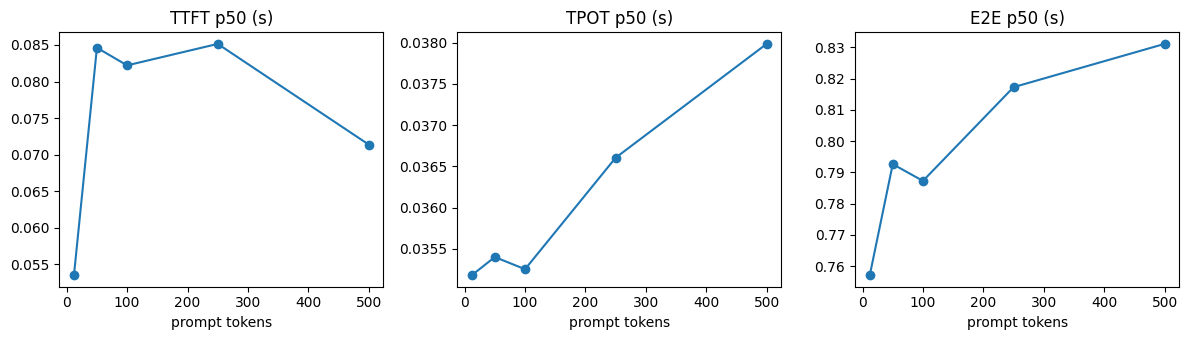

In [7]:
import matplotlib.pyplot as plt

x = df["measured_prompt_tokens"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot(x, df["ttft_p50_s"], marker="o")
axes[0].set_title("TTFT p50 (s)")
axes[0].set_xlabel("prompt tokens")

axes[1].plot(x, df["tpot_p50_s"], marker="o")
axes[1].set_title("TPOT p50 (s)")
axes[1].set_xlabel("prompt tokens")

axes[2].plot(x, df["e2e_p50_s"], marker="o")
axes[2].set_title("E2E p50 (s)")
axes[2].set_xlabel("prompt tokens")

plt.tight_layout()
plt.show()

## Explain

1. Did TTFT grow roughly with prompt length? Linear? Sublinear?
2. Did TPOT stay flat (decode length fixed ~20)?
3. How much of E2E growth is TTFT vs TPOT×tokens?
4. Any cliff near 512 (worker `max_length`)?

### Notes

- …